I've come to find that the spotipy library is a helpful addon for accessing Spotify's API capabilities in this project.

In [13]:
import spotipy
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
from spotipy.oauth2 import SpotifyClientCredentials
import time
import os
from dotenv import load_dotenv
import numpy as np
from scipy.io import wavfile
from scipy.fft import rfft, rfftfreq

API Credentials

I did some external research and found that for security reasons, I should try the python-dotenv package.

In [2]:
load_dotenv()

CLIENT_ID = os.getenv('SPOTIFY_CLIENT_ID')
CLIENT_SECRET = os.getenv('SPOTIFY_CLIENT_SECRET')

sp = spotipy.Spotify(auth_manager=SpotifyClientCredentials(client_id=CLIENT_ID, client_secret=CLIENT_SECRET))

data = []

Spotify imposed some changes within their API leading to some frustrations within the data collection process.
I've created a new loop to work with the data available to us.

I'm currently looking to supplement this data with another API to find song key + bpm.

In [11]:
files = ['billboard_songs.txt', 'non_appearing.txt']

for filename in files:
    with open(filename, 'r', encoding='utf-8') as file:
        for line in file:
            if ',' not in line: 
                continue
                
            title, artist = line.strip().split(', ', 1)
            
            primary_artist = artist.split(' & ')[0].split(' Featuring ')[0]
            
            search = sp.search(q=f"track:{title} artist:{primary_artist}", type='track', limit=1)
            
            if search['tracks']['items']:
                track = search['tracks']['items'][0]
                
                row_data = {
                    'Title': title, 
                    'Artist': artist, 
                    'Popularity': track['popularity'],
                    'Duration_MS': track['duration_ms'],
                    'Explicit': track['explicit'],
                    'Release_Date': track['album']['release_date'],
                    'Album_Name': track['album']['name']
                }
                
                data.append(row_data)  

            time.sleep(0.2)

Export the data to the spotify.csv

In [12]:
pd.DataFrame(data).to_csv('spotify.csv', index=False)

Merge metrics and spotify csv to data.csv

In [14]:
df1 = pd.read_csv('metrics.csv')
df2 = pd.read_csv('spotify.csv')

df1['Title'], df1['Artist'] = df1['Title'].str.strip(), df1['Artist'].str.strip()
df2['Title'], df2['Artist'] = df2['Title'].str.strip(), df2['Artist'].str.strip()

df = pd.merge(df1, df2, on=['Title', 'Artist'], how='inner')

with open('billboard_songs.txt', 'r', encoding='utf-8') as f:
    billboard_titles = [line.split(',')[0].strip() for line in f if ',' in line]

df['Hit'] = df['Title'].isin(billboard_titles).astype(int)

df.to_csv('data.csv', index=False)

In [15]:
df = pd.get_dummies(df, columns=['Key'], drop_first=True)

In [16]:
def get_scipy_fourier(title):
    path = f"Tracks/WAV/{title}.wav"
    if not os.path.exists(path): 
        return pd.Series([np.nan, np.nan])
    
    try:
        sr, data = wavfile.read(path)
        
        # converting tracks to mono
        if data.ndim > 1: data = data.mean(axis=1)
        
        mid = len(data) // 2
        snippet = data[max(0, mid - 15*sr) : min(len(data), mid + 15*sr)]
        
        yf, xf = np.abs(rfft(snippet)), rfftfreq(len(snippet), 1/sr)
        
        return pd.Series([xf[np.argmax(yf)], np.sum(xf * yf) / (np.sum(yf) + 1e-9)])
    except:
        return pd.Series([np.nan, np.nan])

df[['Peak_Freq', 'Mean_Freq']] = df['Title'].apply(get_scipy_fourier)

print(df[['Title', 'Hit', 'Peak_Freq', 'Mean_Freq']].head())

                Title  Hit  Peak_Freq    Mean_Freq
0                APT.    1  54.633333  3443.499464
1    Die With A Smile    1  69.433333  3096.067638
2  Birds Of A Feather    1  49.000000  2903.022875
3            Ordinary    1  82.400000  2611.770990
4    Beautiful Things    1  88.666667  3835.166585


In [17]:
features = ['Duration_MS', 'BPM', 'Peak_Freq', 'Mean_Freq'] + [c for c in df.columns if 'Key_' in c]
df_clean = df.dropna(subset=features + ['Hit']).reset_index(drop=True)

X = df_clean[features]
y = df_clean['Hit']

In [18]:
loo = LeaveOneOut()
y_true, y_pred = [], []

Leave One Out CV

In [19]:
for train_index, test_index in loo.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    log_reg = LogisticRegression(max_iter=1000)
    log_reg.fit(X_train_scaled, y_train)
    
    y_true.append(y_test.values[0])
    y_pred.append(log_reg.predict(X_test_scaled)[0])

Results

In [32]:
print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))
final_model = LogisticRegression(max_iter=1000).fit(StandardScaler().fit_transform(X), y)
weights = pd.DataFrame({'Feature': X.columns, 'Weight': final_model.coef_[0]})
print(weights.sort_values(by='Weight', key=abs, ascending=False).head(5))

[[ 2  5]
 [ 3 15]]
              precision    recall  f1-score   support

           0       0.40      0.29      0.33         7
           1       0.75      0.83      0.79        18

    accuracy                           0.68        25
   macro avg       0.57      0.56      0.56        25
weighted avg       0.65      0.68      0.66        25

        Feature    Weight
0   Duration_MS -1.006152
9        Key_3A -0.909592
14       Key_6B -0.695354
18       Key_9B -0.625430
2     Peak_Freq -0.539515


Creating data visualizations

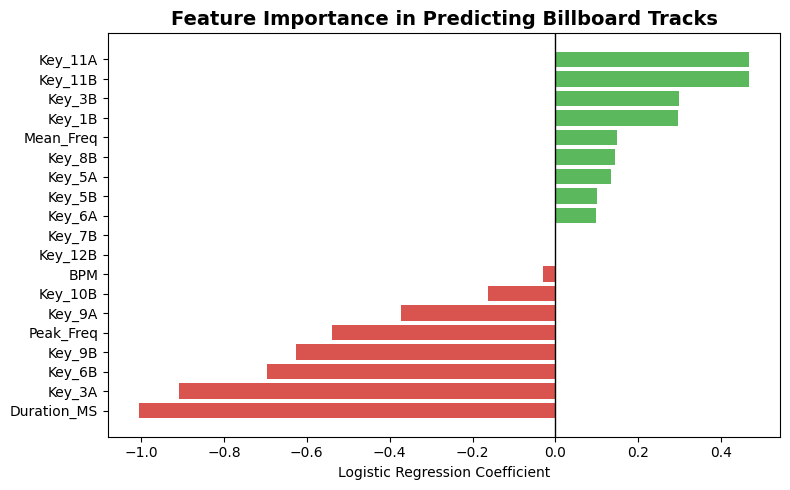

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sorted_weights = weights.sort_values(by='Weight', ascending=True)

colors = ['#d9534f' if x < 0 else '#5cb85c' for x in sorted_weights['Weight']]
plt.barh(sorted_weights['Feature'], sorted_weights['Weight'], color=colors)

plt.axvline(0, color='black', linewidth=1)
plt.title('Feature Importance in Predicting Billboard Tracks', fontsize=14, fontweight='bold')
plt.xlabel('Logistic Regression Coefficient')
plt.tight_layout()
plt.show()

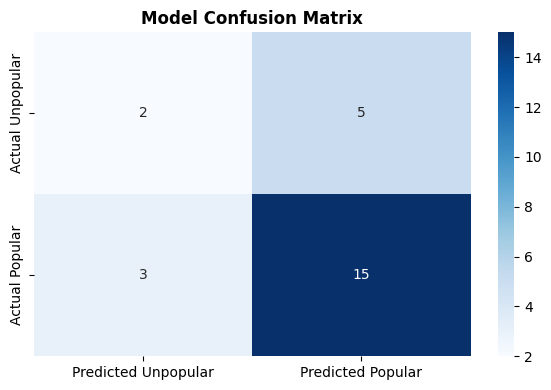

In [30]:
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Unpopular', 'Predicted Popular'],
            yticklabels=['Actual Unpopular', 'Actual Popular'])

plt.title('Model Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()